# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# Assignment Pipeline

1. 📘 Problem Statement
2. 📥 Load Text Corpus
3. 🔤 Tokenization & Sequence Creation
4. 🧠 Model 1: Vanilla RNN
5. 🔒 Model 2: LSTM
6. ⚡ Model 3: GRU
7. 📉 Compare Training Loss
8. ✍️ Text Generation Function
9. 🧪 Generate Text Samples
10. 📚 Student Learning Tasks 
11. ✅ Conclusion

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [42]:
corpus = '''
be yourself everyone else is already taken
you gotta dance like theres nobody watching
be the change that you wish to see in the world
no one can make you feel inferior without your consent
live as if you were to die tomorrow learn as if you were to live forever
darkness cannot drive out darkness only light can do that
without music life would be a mistake
we accept the love we think we deserve
imperfection is beauty madness is genius
there are only two ways to live your life
we are all in the gutter but some of us are looking at the stars
yesterday is history tomorrow is mystery today is a gift
i have not failed ive just found ways that wont work
you have brains in your head you have feet in your shoes
this life is what you make it
there is no greater agony than bearing an untold story
you can never cross the ocean unless you have the courage to lose sight of the shore
life isnt about finding yourself life is about creating yourself
do what you can with all you have wherever you are
success is not final failure is not fatal it is the courage to continue
'''
print(corpus)


be yourself everyone else is already taken
you gotta dance like theres nobody watching
be the change that you wish to see in the world
no one can make you feel inferior without your consent
live as if you were to die tomorrow learn as if you were to live forever
darkness cannot drive out darkness only light can do that
without music life would be a mistake
we accept the love we think we deserve
imperfection is beauty madness is genius
there are only two ways to live your life
we are all in the gutter but some of us are looking at the stars
yesterday is history tomorrow is mystery today is a gift
i have not failed ive just found ways that wont work
you have brains in your head you have feet in your shoes
this life is what you make it
there is no greater agony than bearing an untold story
you can never cross the ocean unless you have the courage to lose sight of the shore
life isnt about finding yourself life is about creating yourself
do what you can with all you have wherever you are


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [43]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 121
X shape: (188, 16)
y shape: (188,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [44]:
rnn_model = Sequential([
    Embedding(total_words,64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [66]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128,return_sequences=True),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [46]:
gru_model = Sequential([
    Embedding(total_words,64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

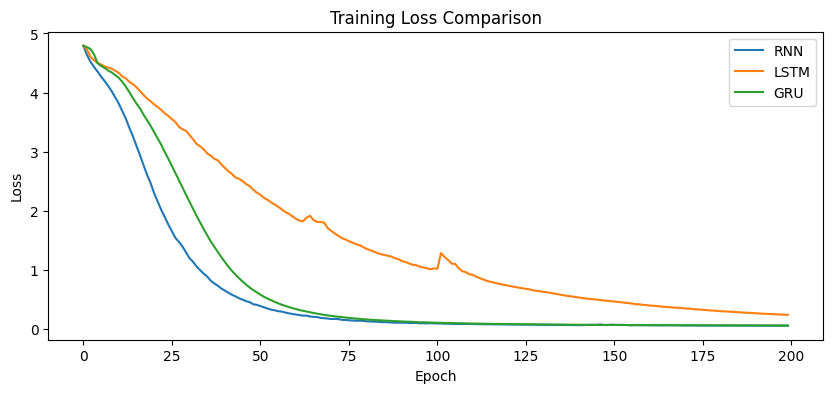

In [67]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [68]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [69]:
print("RNN :", generate_text(rnn_model, "life is", 10))
print("LSTM:", generate_text(lstm_model, "life is", 10))
print("GRU :", generate_text(gru_model, "life is", 10))

RNN : life is about finding yourself life is about creating yourself life is
LSTM: life is history tomorrow is mystery today is a gift gift gift
GRU : life is about creating yourself life is about creating yourself life is


In [63]:
print("RNN :", generate_text(rnn_model, "life is", 10))
print("LSTM:", generate_text(lstm_model, "believe you can", 10))
print("GRU :", generate_text(gru_model, "do what you", 10))

RNN : life is about finding yourself life is about creating yourself life is
LSTM: believe you can never cross the ocean unless you have the courage to
GRU : do what you can with all you have wherever you are looking at


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion

- Used a motivational quotes corpus with 200 epochs, embedding size 64 and 128 hidden units
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better and i used 2 stacked layers, took longer to converge but generated the most meaningful text
- **GRU** gives similar performance with fewer gates and faster training so i used a single layer, converged smoothly and gave clean outputs similar to LSTM
- Overall LSTM and GRU both generated meaningful text, with GRU being faster and simpler to train